# BikeCity 심화 4~5 : 시각화 & 이용자 분석
- 정제 완료 데이터(`transform()` 결과, 13,501행) 사용

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from extract import extract
from transform import transform

# 한글 폰트
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

stations, bikes, rentals = extract()
final, report = transform(stations, bikes, rentals)

print(f"최종 데이터 : {final.shape}")

최종 데이터 : (13501, 16)


## [심화 4] 시각화
#### 자치구별 매출

[자치구별 매출]
district
강북구    4,180,470원
금천구    2,978,700원
관악구    2,745,740원
강동구    2,248,050원
도봉구    1,880,620원
광진구    1,495,470원
강서구    1,152,480원
강남구    1,048,310원
노원구      471,350원
구로구      368,430원
Name: fee, dtype: str


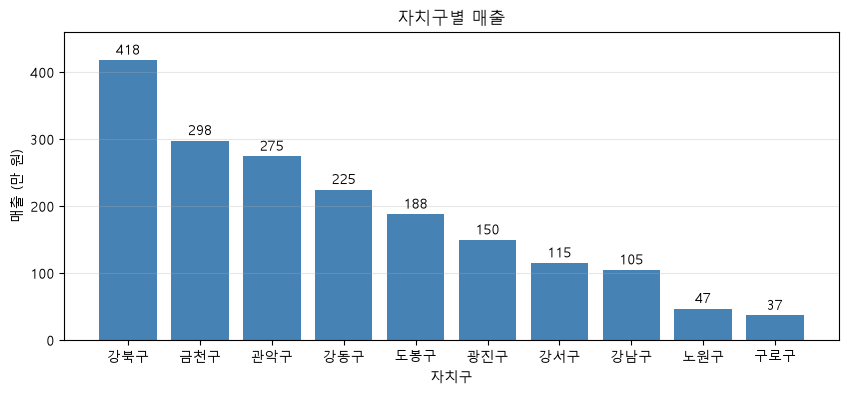

In [2]:
# 자치구별 매출 합계 (결측 자치구 제외)
district_sales = (final.groupby("district")["fee"]
                       .sum()
                       .sort_values(ascending=False))

print("[자치구별 매출]")
display(district_sales.map("{:,.0f}원".format).to_frame("매출"))

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(district_sales.index, district_sales.values / 10000, color="steelblue")
ax.bar_label(bars, fmt="%.0f", padding=2)
ax.set_title("자치구별 매출")
ax.set_ylim(0, district_sales.max() / 10000 * 1.1)   # 위쪽 10% 여유
ax.set_xlabel("자치구")
ax.set_ylabel("매출 (만 원)")
ax.grid(alpha=0.3, axis="y")
plt.show()

#### 시간대별 대여 건수
- 세로축을 0부터 시작해 실제 차이를 정직하게 표시

[시간대별 대여 건수]
rent_time
6     849
7     754
8     835
9     795
10    826
11    791
12    766
13    702
14    785
15    741
16    786
17    777
18    819
19    837
20    827
21    818
22    793
Name: count, dtype: int64


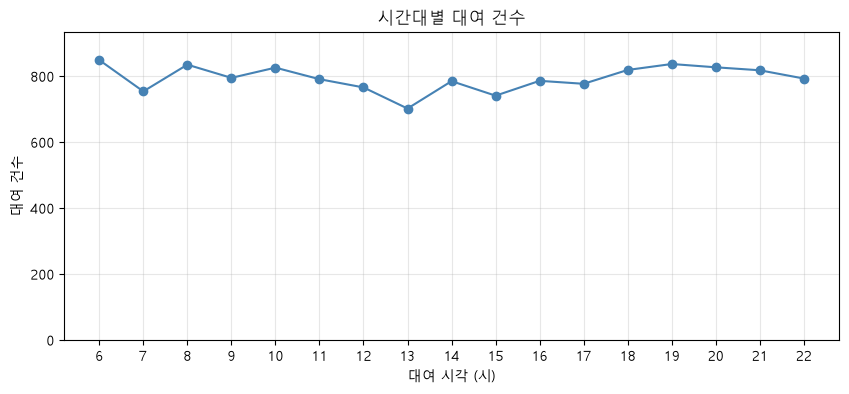

In [3]:
# 시간대별 대여 건수 (운영 시간 6시 ~ 22시)
hour_counts = final["rent_time"].dt.hour.value_counts().sort_index()

print("[시간대별 대여 건수]")
display(hour_counts.to_frame("대여 건수"))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hour_counts.index, hour_counts.values, marker="o", color="steelblue")
ax.set_xticks(range(6, 23))
ax.set_ylim(0, hour_counts.max() * 1.1)
ax.set_title("시간대별 대여 건수")
ax.set_xlabel("대여 시각 (시)")
ax.set_ylabel("대여 건수")
ax.grid(alpha=0.3)
plt.show()

## [심화 5] 이용자 분석
- 이용자당 평균 대여 횟수, 재이용률(2회 이상 이용자 비율)

In [4]:
# 이용자별 대여 횟수
user_counts = final["user_id"].value_counts()

print(f"이용자 수 : {len(user_counts):,}명")
print(f"이용자당 평균 대여 횟수 : {user_counts.mean():.2f}회")
print(f"중앙값 : {user_counts.median():.0f}회, 최소 {user_counts.min()}회, 최대 {user_counts.max()}회")

이용자 수 : 1,999명
이용자당 평균 대여 횟수 : 6.75회
중앙값 : 6회, 최소 1회, 최대 18회


In [5]:
# 재이용률 = 2회 이상 이용자 비율
repeat = user_counts >= 2

print(f"재이용자 : {repeat.sum():,}명 / {len(user_counts):,}명")
print(f"재이용률 : {repeat.mean():.1%}")

재이용자 : 1,977명 / 1,999명
재이용률 : 98.9%
